# 00. Данные, целевая формула, предобработка и EDA

Ноутбук фиксирует главное правило проекта: модель не использует поведенческие статистики прохождения ребуса, потому что `difficulty` вычисляется из них напрямую. В качестве входных данных модели допустимы только `answer`, `description` и признаки изображения.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Загрузка данных

In [2]:
DATA_PATH = Path("../data.csv")
df = pd.read_csv(DATA_PATH)

print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")
df.head()

Rows: 327
Columns: 13


,id,answer,description,date_posted,img_url,started,solved,users_with_hints,total_hints,solve_rate,hint_usage,avg_hints,difficulty
0,1,брауни,Коричневая английская Е (читается как и) = Bro...,2025-06-01,/daily-rebuses/1_v1.jpg,454,219,110,179,0.4824,0.2423,0.3943,0.4303
1,2,tralalelo tralala|тралалело тралала|тралалеро ...,Один из самых известных героев мема BrainRot -...,2025-06-02,/daily-rebuses/2.jpg,339,162,65,90,0.4779,0.1917,0.2655,0.4010
2,3,свитер|свита,Свитер или Свита. Сладкая буква R. (sweet R). ...,2025-06-03,/daily-rebuses/3_v1.jpg,276,134,38,56,0.4855,0.1377,0.2029,0.3736
3,4,подоконник,Под О Конь и К,2025-06-04,/daily-rebuses/4.jpg,255,183,19,28,0.7176,0.0745,0.1098,0.2045
4,5,редактор,Красный актер = Red Actor,2025-06-05,/daily-rebuses/5_v1.jpg,311,200,96,158,0.6431,0.3087,0.5080,0.3675


## Формула difficulty и запрет утечки

В поле `DIFFICULTY_FORMULA` - фактическая формула расчета сложности. Все столбцы, участвующие в этой формуле, считаются leakage-признаками и не должны попадать в обучение модели.

In [3]:
DIFFICULTY_FORMULA = """
Если started == 0, difficulty = 0.
Иначе:
difficulty = 0.6 * (1 - solved / started)
           + 0.25 * (users_with_hints / started)
           + 0.15 * (total_hints / started)
""".strip()

LEAKAGE_COLUMNS = [
    "started",
    "solved",
    "users_with_hints",
    "total_hints",
    "solve_rate",
    "hint_usage",
    "avg_hints",
]

FORMULA_COLUMNS = ["started", "solved", "users_with_hints", "total_hints"]
ALLOWED_RAW_INPUTS = ["answer", "description", "img_url"]
TARGET = "difficulty"


def calculate_difficulty(frame):
    started = frame["started"].replace(0, np.nan)
    calculated = (
        0.6 * (1 - frame["solved"] / started)
        + 0.25 * (frame["users_with_hints"] / started)
        + 0.15 * (frame["total_hints"] / started)
    )
    return calculated.fillna(0)


pd.DataFrame(
    [
        {"column_group": "allowed_model_inputs", "columns": ALLOWED_RAW_INPUTS},
        {"column_group": "target", "columns": [TARGET]},
        {"column_group": "formula_columns", "columns": FORMULA_COLUMNS},
        {"column_group": "forbidden_leakage_columns", "columns": LEAKAGE_COLUMNS},
    ]
)


,column_group,columns
0,allowed_model_inputs,"[answer, description, img_url]"
1,target,[difficulty]
2,formula_columns,"[started, solved, users_with_hints, total_hints]"
3,forbidden_leakage_columns,"[started, solved, users_with_hints, total_hint..."


## Проверка расчета difficulty

Сверяем целевую колонку с формулой. Это не feature engineering для модели, а проверка происхождения target и подтверждение, почему формульные столбцы запрещены как признаки.

In [4]:
difficulty_check = df[["difficulty", *FORMULA_COLUMNS]].copy()
difficulty_check["difficulty_calculated"] = calculate_difficulty(df)
difficulty_check["absolute_diff"] = (difficulty_check["difficulty"] - difficulty_check["difficulty_calculated"]).abs()

print(f"Max absolute difference: {difficulty_check['absolute_diff'].max():.8f}")
print(f"Mean absolute difference: {difficulty_check['absolute_diff'].mean():.8f}")

difficulty_check.sort_values("absolute_diff", ascending=False).head(10)


Max absolute difference: 0.00004981
Mean absolute difference: 0.00002555


,difficulty,started,solved,users_with_hints,total_hints,difficulty_calculated,absolute_diff
66,0.3431,781,767,493,909,0.343150,0.000050
283,0.2882,1384,1369,700,1432,0.288150,0.000050
288,0.0433,1326,1325,137,150,0.043250,0.000050
2,0.3736,276,134,38,56,0.373551,0.000049
76,0.2358,795,782,396,538,0.235849,0.000049
162,0.1506,1089,1083,324,529,0.150551,0.000049
82,0.2396,826,820,394,639,0.239649,0.000049
184,0.1787,1127,1108,402,597,0.178749,0.000049
277,0.1399,1368,1365,344,691,0.139949,0.000049
153,0.0377,1057,1057,96,106,0.037748,0.000048


## Описание признаков

In [5]:
feature_description = pd.DataFrame(
    [
        ("id", "идентификатор ребуса; не используется как модельный признак"),
        ("answer", "правильный ответ или варианты через |; допустимый источник признаков"),
        ("description", "текстовое описание логики ребуса; допустимый источник признаков"),
        ("date_posted", "дата публикации; не используется в модели"),
        ("img_url", "путь к изображению; используется для извлечения image-features"),
        ("started", "служебная статистика прохождения; запрещена для модели"),
        ("solved", "служебная статистика прохождения; запрещена для модели"),
        ("users_with_hints", "служебная статистика подсказок; запрещена для модели"),
        ("total_hints", "служебная статистика подсказок; запрещена для модели"),
        ("solve_rate", "производная статистика прохождения; запрещена для модели"),
        ("hint_usage", "производная статистика подсказок; запрещена для модели"),
        ("avg_hints", "производная статистика подсказок; запрещена для модели"),
        ("difficulty", "целевая переменная; рассчитывается по формуле выше"),
    ],
    columns=["feature", "description"],
)
feature_description

,feature,description
0,id,идентификатор ребуса; не используется как моде...
1,answer,правильный ответ или варианты через |; допусти...
2,description,текстовое описание логики ребуса; допустимый и...
3,date_posted,дата публикации; не используется в модели
4,img_url,путь к изображению; используется для извлечени...
5,started,служебная статистика прохождения; запрещена дл...
6,solved,служебная статистика прохождения; запрещена дл...
7,users_with_hints,служебная статистика подсказок; запрещена для ...
8,total_hints,служебная статистика подсказок; запрещена для ...
9,solve_rate,производная статистика прохождения; запрещена ...


## Пропуски и типы данных

In [6]:
missing_report = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum(),
        "missing_share": df.isna().mean(),
        "unique_count": df.nunique(dropna=True),
        "model_usage": [
            "allowed" if col in ALLOWED_RAW_INPUTS else "target" if col == TARGET else "forbidden/leakage" if col in LEAKAGE_COLUMNS else "not_used"
            for col in df.columns
        ],
    }
).sort_values(["model_usage", "missing_count"], ascending=[True, False])

missing_report

,dtype,missing_count,missing_share,unique_count,model_usage
answer,object,0,0.0,326,allowed
description,object,0,0.0,327,allowed
img_url,object,0,0.0,327,allowed
started,int64,0,0.0,269,forbidden/leakage
solved,int64,0,0.0,255,forbidden/leakage
users_with_hints,int64,0,0.0,263,forbidden/leakage
total_hints,int64,0,0.0,305,forbidden/leakage
solve_rate,float64,0,0.0,229,forbidden/leakage
hint_usage,float64,0,0.0,319,forbidden/leakage
avg_hints,float64,0,0.0,325,forbidden/leakage


## Feature engineering только из answer и description

In [7]:
VOWELS = set("аеёиоуыэюя")
RARE_LETTERS = set("фщъёцэ")

eda_df = df.copy()
eda_df["answer_main"] = eda_df["answer"].astype(str).str.split("|").str[0].str.strip()
eda_df["answer_compact"] = eda_df["answer_main"].str.replace(" ", "", regex=False)
eda_df["answer_len"] = eda_df["answer_compact"].str.len()
eda_df["answer_word_count"] = eda_df["answer_main"].str.split().str.len()
eda_df["description_len"] = eda_df["description"].astype(str).str.len()
eda_df["description_word_count"] = eda_df["description"].astype(str).str.split().str.len()
eda_df["variant_count"] = eda_df["answer"].astype(str).str.count(r"\|") + 1
eda_df["answer_vowel_ratio"] = eda_df["answer_compact"].apply(
    lambda text: sum(char in VOWELS for char in str(text).lower()) / len(str(text)) if len(str(text)) else 0.0
)
eda_df["answer_rare_ratio"] = eda_df["answer_compact"].apply(
    lambda text: sum(char in RARE_LETTERS for char in str(text).lower()) / len(str(text)) if len(str(text)) else 0.0
)
eda_df["description_has_rebus_terms"] = eda_df["description"].astype(str).str.lower().str.contains(
    "запятая|перевернут|зачерк|буква|цифра", regex=True
).astype(int)

engineered_cols = [
    "answer_len",
    "answer_word_count",
    "description_len",
    "description_word_count",
    "variant_count",
    "answer_vowel_ratio",
    "answer_rare_ratio",
    "description_has_rebus_terms",
]

eda_df[["answer", "description", *engineered_cols, "difficulty"]].head()

,answer,description,answer_len,answer_word_count,description_len,description_word_count,variant_count,answer_vowel_ratio,answer_rare_ratio,description_has_rebus_terms,difficulty
0,брауни,Коричневая английская Е (читается как и) = Bro...,6,1,72,13,1,0.500000,0.0,0,0.4303
1,tralalelo tralala|тралалело тралала|тралалеро ...,Один из самых известных героев мема BrainRot -...,16,2,65,11,4,0.000000,0.0,0,0.4010
2,свитер|свита,Свитер или Свита. Сладкая буква R. (sweet R). ...,6,1,73,15,2,0.333333,0.0,1,0.3736
3,подоконник,Под О Конь и К,10,1,14,5,1,0.400000,0.0,0,0.2045
4,редактор,Красный актер = Red Actor,8,1,25,5,1,0.375000,0.0,0,0.3675


## Проверка, что leakage-колонки не входят в признаки

In [8]:
model_feature_candidates = engineered_cols
leakage_intersection = sorted(set(model_feature_candidates) & set(LEAKAGE_COLUMNS))
assert not leakage_intersection, leakage_intersection

pd.DataFrame({"model_feature_candidate": model_feature_candidates})

,model_feature_candidate
0,answer_len
1,answer_word_count
2,description_len
3,description_word_count
4,variant_count
5,answer_vowel_ratio
6,answer_rare_ratio
7,description_has_rebus_terms


## График 1: распределение difficulty

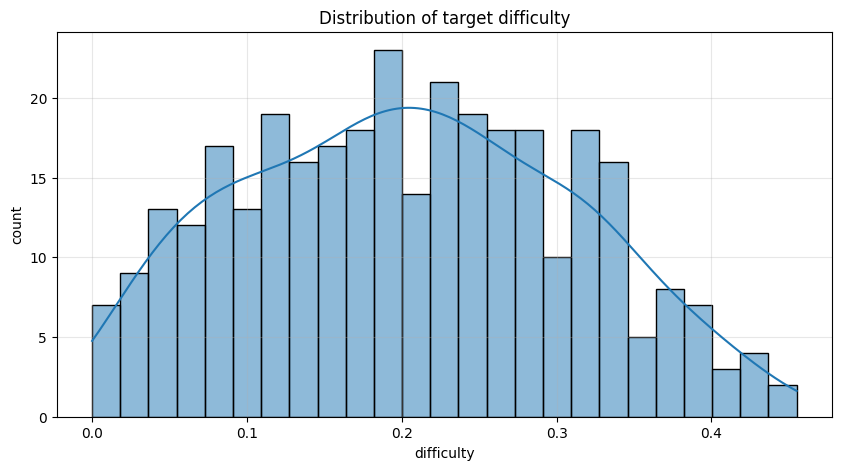

In [9]:
plt.figure(figsize=(10, 5))
sns.histplot(eda_df["difficulty"], bins=25, kde=True)
plt.title("Distribution of target difficulty")
plt.xlabel("difficulty")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

## График 2: распределение длины answer

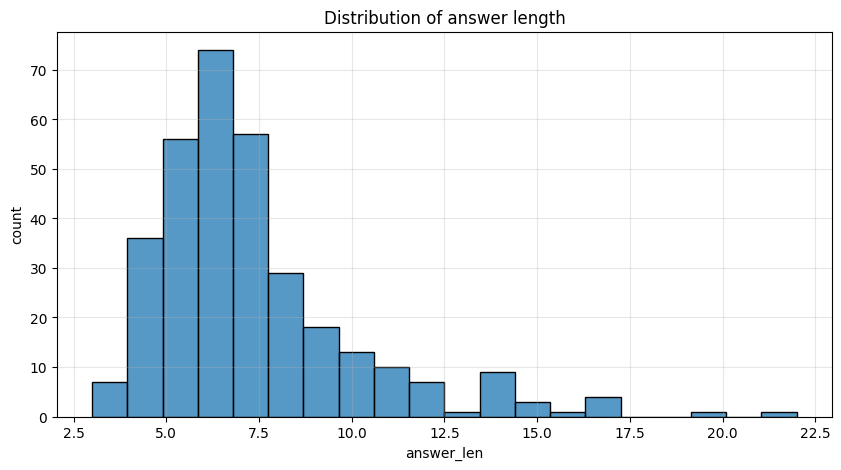

In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(eda_df["answer_len"], bins=20)
plt.title("Distribution of answer length")
plt.xlabel("answer_len")
plt.ylabel("count")
plt.grid(True, alpha=0.3)
plt.show()

## График 3: длина answer и difficulty

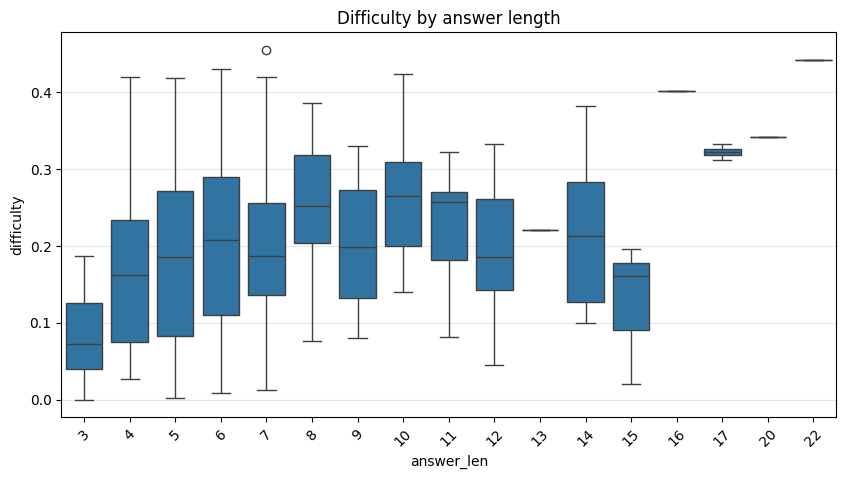

In [11]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=eda_df, x="answer_len", y="difficulty")
plt.title("Difficulty by answer length")
plt.xlabel("answer_len")
plt.ylabel("difficulty")
plt.xticks(rotation=45)
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## График 4: длина description и difficulty

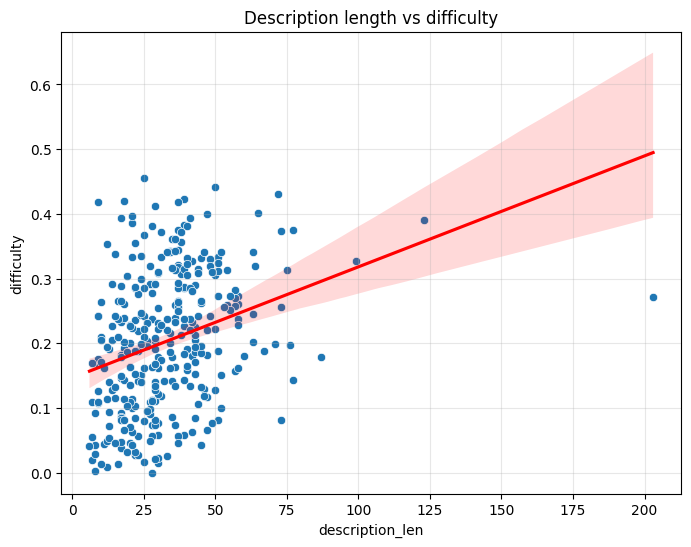

In [12]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=eda_df, x="description_len", y="difficulty")
sns.regplot(data=eda_df, x="description_len", y="difficulty", scatter=False, color="red")
plt.title("Description length vs difficulty")
plt.grid(True, alpha=0.3)
plt.show()

## График 5: число вариантов answer и difficulty

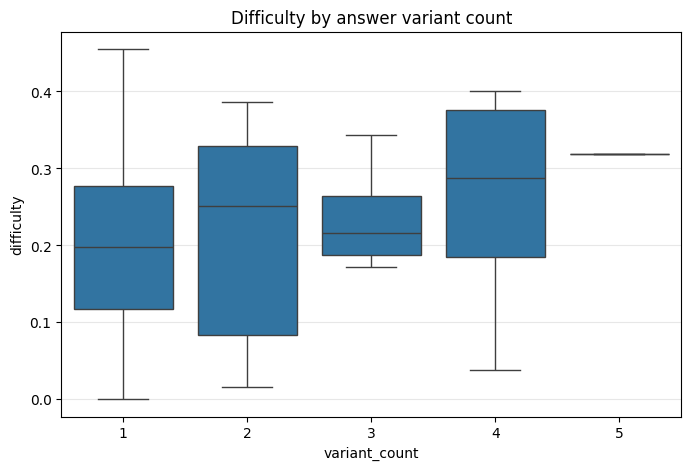

In [13]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=eda_df, x="variant_count", y="difficulty")
plt.title("Difficulty by answer variant count")
plt.xlabel("variant_count")
plt.ylabel("difficulty")
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## График 6: корреляции разрешенных engineered-признаков

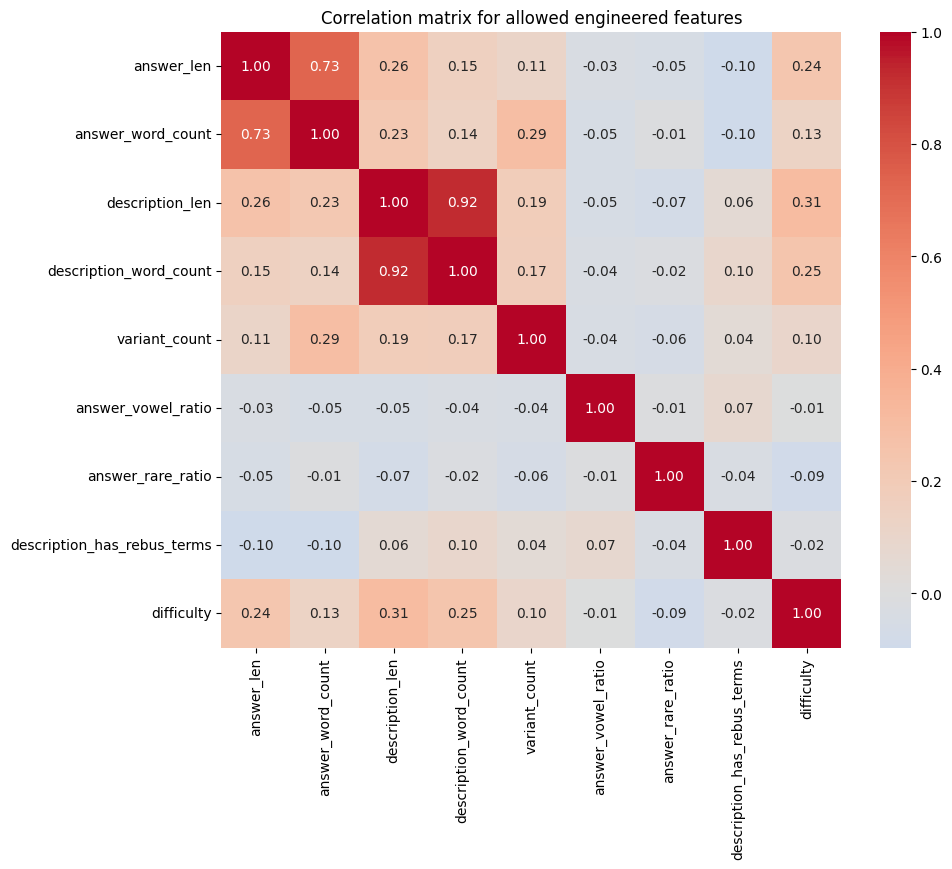

difficulty                     1.000000
description_len                0.311912
description_word_count         0.247435
answer_len                     0.236112
answer_word_count              0.134232
variant_count                  0.097395
answer_vowel_ratio            -0.005381
description_has_rebus_terms   -0.018176
answer_rare_ratio             -0.090502
Name: difficulty, dtype: float64

In [14]:
corr_cols = [*engineered_cols, "difficulty"]
corr = eda_df[corr_cols].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Correlation matrix for allowed engineered features")
plt.show()

corr["difficulty"].sort_values(ascending=False)

## Выводы EDA

In [15]:
eda_conclusions = [
    "difficulty является целевой переменной и не должна объясняться через статистики, из которых она была рассчитана.",
    "started, solved, users_with_hints, total_hints, solve_rate, hint_usage и avg_hints являются leakage-колонками и исключаются из моделирования.",
    "Разрешенный feature engineering строится только из answer и description: длины, число слов, варианты ответа, буквенные ratios и текстовые триггеры.",
    "Корреляции разрешенных текстовых признаков с difficulty слабее, чем у leakage-статистик, поэтому дополнительно используются NLP и image-features.",
]

for i, conclusion in enumerate(eda_conclusions, 1):
    print(f"{i}. {conclusion}")

1. difficulty является целевой переменной и не должна объясняться через статистики, из которых она была рассчитана.
2. started, solved, users_with_hints, total_hints, solve_rate, hint_usage и avg_hints являются leakage-колонками и исключаются из моделирования.
3. Разрешенный feature engineering строится только из answer и description: длины, число слов, варианты ответа, буквенные ratios и текстовые триггеры.
4. Корреляции разрешенных текстовых признаков с difficulty слабее, чем у leakage-статистик, поэтому дополнительно используются NLP и image-features.
